# Quantitative Thinking Problems

Problems by Stephen Weissenhofer, Haskell Solutions by Frank Jung

## Problem 3

In the center of Memorial Park is a fountain in the shape of a hexagon. Workers are
ringing the fountain in hexagonal tiles. The first ring is made of black tiles; the next one
grey tiles; the next black, and so on. How many hexagonal tiles will the workers use in
the fourth ring? In all, the workers completed 15 rings. What colour were the tiles in
the fifteenth ring? How many did they need for this ring?

| ring   | hexagons colour |
| -------|-----------------|
| ring 1 |  6 black |
| ring 2 | 12 grey |
| ring 3 | 18 black |
| ...    | .. ..... |
| ring n | `n * 6` if `n` is *odd* then *black* else *grey* |

So for ring `15` there are `90` **black** heaxagons.

## Problem 6

I have a book with 100 pages, numbered 1 to 100. If I look at all 100 pages, how many
times will I see the number 1 printed?

In [1]:
-- naïve count of ones in a digit of a page number
ones :: Char -> Int
ones c = if c == '1' then 1 else 0

-- count all ones in a book of 1 to n pages
solve :: Int -> Int
solve n = sum ((map ones . show) [1..n])

Number of 1's in a 100 page book:

In [2]:
solve 100

21

## Problem 7

I'm reading a much bigger book now, with 1150 pages. How many 1's occur in the pages
1 to 1150?

Number of 1's in a 1150 page book:

In [3]:
solve 1150

537

## Problem 8

Another version to problems 6 & 7 is this one:

> I have a book with 777 pages, numbered 1 to 777. If I look at all 777 pages, how many times will I see the number 7 printed?

A generalised version of this question is:

> I have a book with _nnn_ pages, numbered 1 to _nnn_. If I look at all _nnn_ pages, how many times will I see the number _n_ printed? Where is a digit from 1 to 9.

We will solve for this more general case in two ways: 

1. Firstly we will update our script for the generalised case
1. Next, we will look for a general pattern in the answers

### Generalise the script

Change the script to accept an additional parameter, being the digit to filter for:

In [4]:
import           Data.Char          (intToDigit)

-- primitive count of ones in a character
digit :: Char -> Char -> Int
digit d c = if c == d then 1 else 0

-- count all digits in a list of pages
solve :: Int -> Int -> Int
solve i n = sum ((map di . show) [1..n])
  where di = digit (intToDigit i)

Now we can use this to produce a few use cases:

In [5]:
zipWith solve [6,7,8] [666,777,888]

[201,234,267]

While it solves the problem, it doesn't really help to understand what is going on. Let us reduce the example.

In [6]:
zipWith solve [1,1,1] [1,11,111]

[1,4,36]

What is the general form for this? Consider the digit _1_. It appears 20 times in 1-99. From then we add another ...

## Problems 10,11 and 12

In figure below the pentagon has 10 circles, 5 at each corner, 5 in the middles of the edges.
Place the numbers 1 to 10 in the circles so that each side sums to the same value.
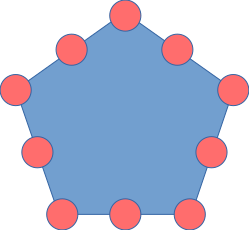

### Solotions

Find solutions where all sides sum to equal value. First label the corners:

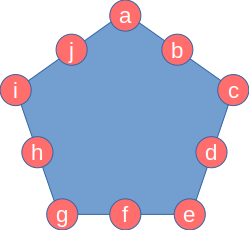

Now, using a similar method to the magic triangles, search all permutations for which the sums of sides are equal. Here we limit the search to just the first result for a given sum total.

In [7]:
import Data.List
import Data.Maybe

solve :: Int -> Maybe [(Int,Int,Int)]
solve n
    | null ns   = Nothing
    | otherwise = Just (head ns)
    where ns = [ [(a,b,c), (c,d,e), (e,f,g), (g,h,i), (i,j,a)] 
                    | [a,b,c,d,e,f,g,h,i,j] <- permutations [1..10],
                        all (==n) [a+b+c, c+d+e, e+f+g, g+h+i, i+j+a] ]

In [8]:
-- solve for sums 10 to 27
solutions = map solve [10..27]

In [9]:
-- show solutions
zip [10..27] solutions

[(10,Nothing),(11,Nothing),(12,Nothing),(13,Nothing),(14,Just [(3,6,5),(5,7,2),(2,8,4),(4,9,1),(1,10,3)]),(15,Nothing),(16,Just [(5,2,9),(9,4,3),(3,6,7),(7,8,1),(1,10,5)]),(17,Just [(6,9,2),(2,7,8),(8,5,4),(4,3,10),(10,1,6)]),(18,Nothing),(19,Just [(8,5,6),(6,4,9),(9,3,7),(7,2,10),(10,1,8)]),(20,Nothing),(21,Nothing),(22,Nothing),(23,Nothing),(24,Nothing),(25,Nothing),(26,Nothing),(27,Nothing)]